# Assignment 01 -- Gradient Descent
**Author:** Wiktor Sosnowski, 348561

In [24]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# add src/assignment_01 to path so imports work from notebook
sys.path.insert(0, os.path.abspath('../../src/assignment_01'))

from functions import sphere, matyas
from gradient_descent import GradientDescent
from visualization import plot_convergence, plot_convergence_log, plot_trajectory

## Experiment 1 -- Effect of learning rate on convergence

Fixed parameters:
- starting point: `x0 = [10.0, 10.0]`
- max iterations: `10000`
- gradient tolerance: `1e-6`

Varied parameter: `learning_rate` in `[0.001, 0.01, 0.1, 0.4, 0.9]`

In [25]:
# --- Experiment 1 configuration ---
X0 = np.array([10.0, 10.0])
MAX_ITER = 10000
GRAD_TOL = 1e-6
LEARNING_RATES = [0.001, 0.01, 0.1, 0.4, 0.9]

# run gradient descent for each learning rate on both functions
results_exp1 = {}
for func_name, func in [("Sphere", sphere), ("Matyas", matyas)]:
    results_exp1[func_name] = {}
    for lr in LEARNING_RATES:
        gd = GradientDescent(learning_rate=lr, max_iter=MAX_ITER, grad_tol=GRAD_TOL)
        result = gd.optimize(func, X0)
        results_exp1[func_name][lr] = result
        status = "converged" if result["converged"] else "max_iter reached"
        print(f"{func_name} | lr={lr:.3f} | iter={result['n_iter']:>6} | f_opt={result['f_opt']:.2e} | {status}")

Sphere | lr=0.001 | iter=  8571 | f_opt=2.49e-13 | converged
Sphere | lr=0.010 | iter=   850 | f_opt=2.43e-13 | converged
Sphere | lr=0.100 | iter=    77 | f_opt=2.38e-13 | converged
Sphere | lr=0.400 | iter=    11 | f_opt=8.39e-14 | converged
Sphere | lr=0.900 | iter=    77 | f_opt=2.38e-13 | converged
Matyas | lr=0.001 | iter= 10000 | f_opt=1.80e+00 | max_iter reached
Matyas | lr=0.010 | iter= 10000 | f_opt=1.34e-03 | max_iter reached
Matyas | lr=0.100 | iter=  3305 | f_opt=1.25e-11 | converged
Matyas | lr=0.400 | iter=   822 | f_opt=1.22e-11 | converged
Matyas | lr=0.900 | iter=   362 | f_opt=1.19e-11 | converged


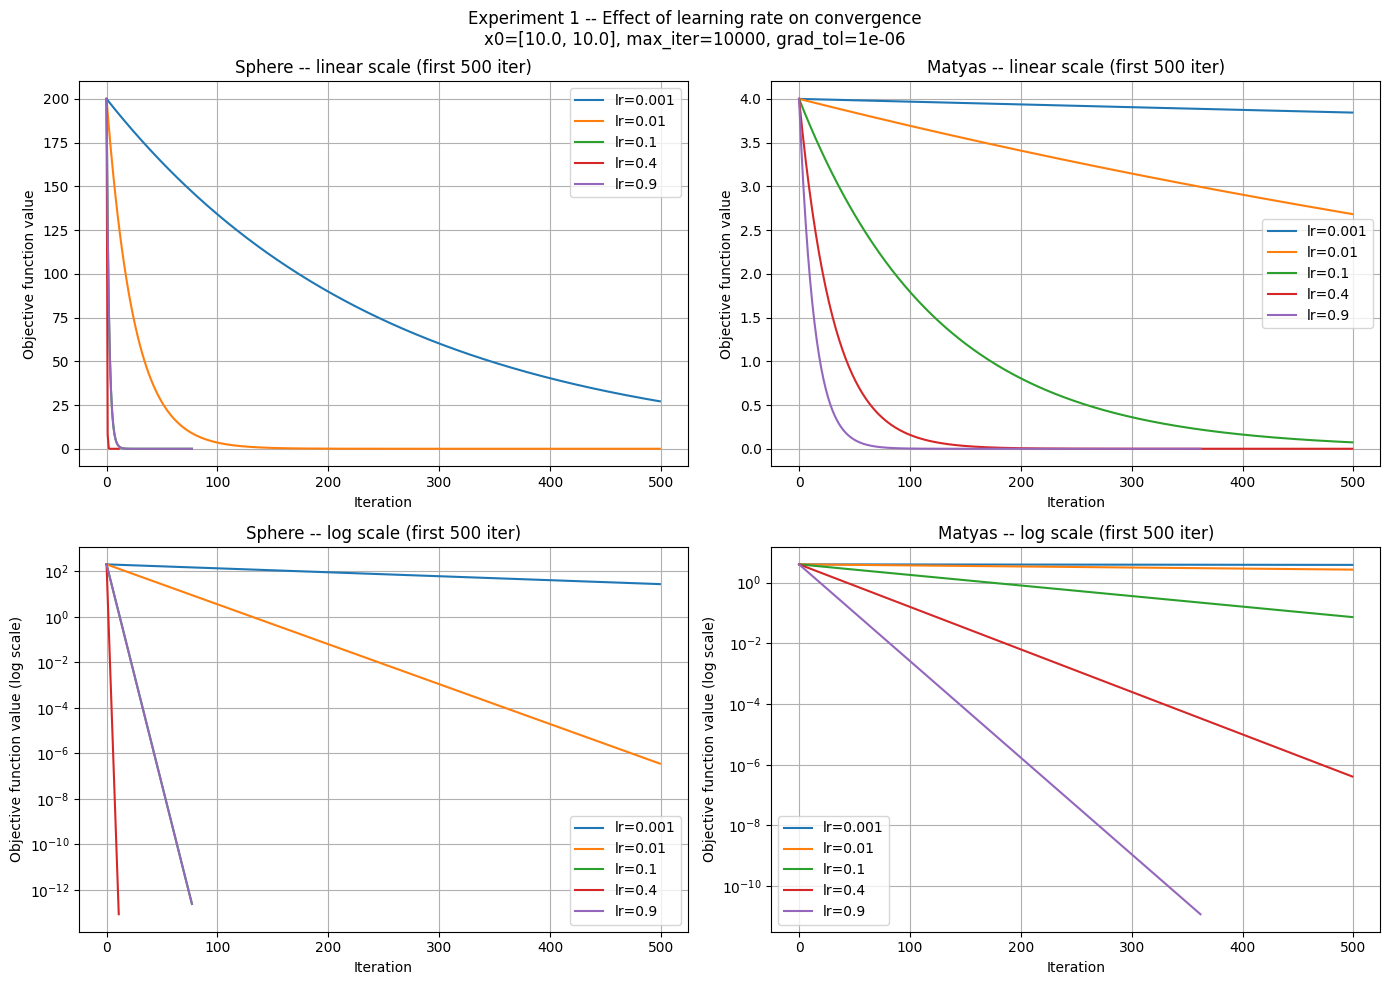

In [26]:
# --- Convergence plots for Experiment 1 ---
# show up to 500 iterations for readability (diverging runs are visible early)
PLOT_ITER_LIMIT = 500

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Experiment 1 -- Effect of learning rate on convergence\n"
             f"x0={X0.tolist()}, max_iter={MAX_ITER}, grad_tol={GRAD_TOL}", fontsize=12)

for col, (func_name, func) in enumerate([("Sphere", sphere), ("Matyas", matyas)]):
    f_histories = []
    labels = []
    for lr in LEARNING_RATES:
        history = results_exp1[func_name][lr]["f_history"][:PLOT_ITER_LIMIT]
        f_histories.append(history)
        labels.append(f"lr={lr}")

    # linear scale
    plot_convergence(
        f_histories, labels,
        title=f"{func_name} -- linear scale (first {PLOT_ITER_LIMIT} iter)",
        ax=axes[0, col]
    )
    # log scale -- better shows differences between converging runs
    plot_convergence_log(
        f_histories, labels,
        title=f"{func_name} -- log scale (first {PLOT_ITER_LIMIT} iter)",
        ax=axes[1, col]
    )

plt.tight_layout()
plt.savefig("experiment1_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

In [27]:
# --- Summary table for Experiment 1 ---
print("Experiment 1 -- Summary table")
print(f"Fixed: x0={X0.tolist()}, max_iter={MAX_ITER}, grad_tol={GRAD_TOL}")
print()

for func_name in ["Sphere", "Matyas"]:
    print(f"Function: {func_name}")
    print(f"{'lr':<8} {'n_iter':>8} {'f_opt':>14} {'converged':>12}")
    print("-" * 46)
    for lr in LEARNING_RATES:
        r = results_exp1[func_name][lr]
        print(f"{lr:<8} {r['n_iter']:>8} {r['f_opt']:>14.6e} {str(r['converged']):>12}")
    print()

Experiment 1 -- Summary table
Fixed: x0=[10.0, 10.0], max_iter=10000, grad_tol=1e-06

Function: Sphere
lr         n_iter          f_opt    converged
----------------------------------------------
0.001        8571   2.493267e-13         True
0.01          850   2.428615e-13         True
0.1            77   2.381705e-13         True
0.4            11   8.388608e-14         True
0.9            77   2.381705e-13         True

Function: Matyas
lr         n_iter          f_opt    converged
----------------------------------------------
0.001       10000   1.797287e+00        False
0.01        10000   1.339705e-03        False
0.1          3305   1.248208e-11         True
0.4           822   1.218995e-11         True
0.9           362   1.185312e-11         True



## Experiment 2 -- Effect of starting point on trajectory

Fixed parameters:
- `learning_rate = 0.1`
- `max_iter = 10000`
- `gradient tolerance = 1e-6`

Varied parameter: starting point `x0` in `[[10, 10], [5, -3], [0, 9]]`

In [28]:
# --- Experiment 2 configuration ---
LR_EXP2 = 0.1
STARTING_POINTS = [
    np.array([10.0, 10.0]),
    np.array([ 5.0, -3.0]),
    np.array([ 0.0,  9.0]),
]

# run gradient descent for each starting point on both functions
results_exp2 = {}
for func_name, func in [("Sphere", sphere), ("Matyas", matyas)]:
    results_exp2[func_name] = {}
    for x0 in STARTING_POINTS:
        gd = GradientDescent(learning_rate=LR_EXP2, max_iter=MAX_ITER, grad_tol=GRAD_TOL)
        result = gd.optimize(func, x0)
        key = tuple(x0)
        results_exp2[func_name][key] = result
        print(f"{func_name} | x0={x0.tolist()} | iter={result['n_iter']:>6} | "
              f"f_opt={result['f_opt']:.2e} | x_opt={result['x_opt'].round(4).tolist()}")

Sphere | x0=[10.0, 10.0] | iter=    77 | f_opt=2.38e-13 | x_opt=[0.0, 0.0]
Sphere | x0=[5.0, -3.0] | iter=    73 | f_opt=2.41e-13 | x_opt=[0.0, -0.0]
Sphere | x0=[0.0, 9.0] | iter=    75 | f_opt=2.35e-13 | x_opt=[0.0, 0.0]
Matyas | x0=[10.0, 10.0] | iter=  3305 | f_opt=1.25e-11 | x_opt=[0.0, 0.0]
Matyas | x0=[5.0, -3.0] | iter=  2731 | f_opt=1.24e-11 | x_opt=[0.0, 0.0]
Matyas | x0=[0.0, 9.0] | iter=  3106 | f_opt=1.25e-11 | x_opt=[0.0, 0.0]


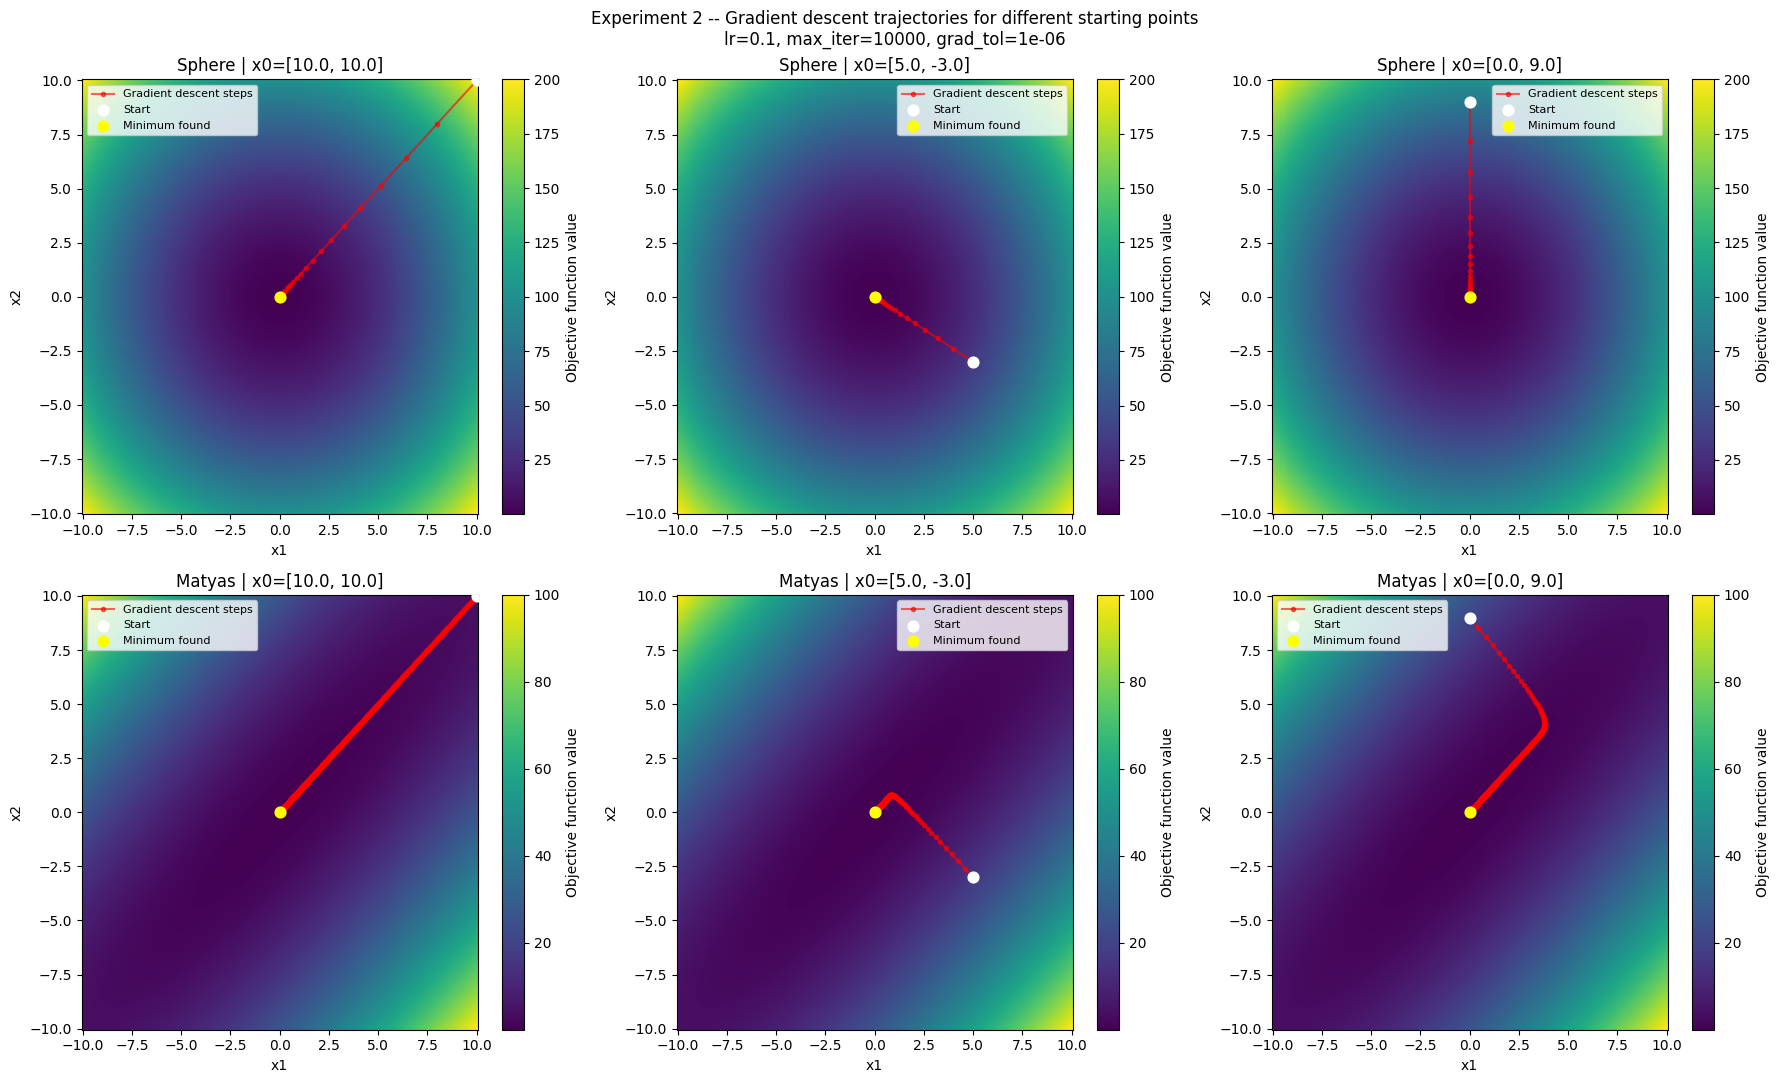

In [29]:
# --- Trajectory plots for Experiment 2 ---
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Experiment 2 -- Gradient descent trajectories for different starting points\n"
             f"lr={LR_EXP2}, max_iter={MAX_ITER}, grad_tol={GRAD_TOL}", fontsize=12)

for row, (func_name, func) in enumerate([("Sphere", sphere), ("Matyas", matyas)]):
    for col, x0 in enumerate(STARTING_POINTS):
        key = tuple(x0)
        trajectory = results_exp2[func_name][key]["trajectory"]
        plot_trajectory(
            func,
            trajectory,
            title=f"{func_name} | x0={x0.tolist()}",
            ax=axes[row, col]
        )

plt.tight_layout()
plt.savefig("experiment2_trajectories.png", dpi=150, bbox_inches="tight")
plt.show()

In [30]:
# --- Summary table for Experiment 2 ---
print("Experiment 2 -- Summary table")
print(f"Fixed: lr={LR_EXP2}, max_iter={MAX_ITER}, grad_tol={GRAD_TOL}")
print()

for func_name in ["Sphere", "Matyas"]:
    print(f"Function: {func_name}")
    print(f"{'x0':<16} {'n_iter':>8} {'f_opt':>14} {'x_opt':>24}")
    print("-" * 66)
    for x0 in STARTING_POINTS:
        key = tuple(x0)
        r = results_exp2[func_name][key]
        print(f"{str(x0.tolist()):<16} {r['n_iter']:>8} {r['f_opt']:>14.6e} "
              f"{str(r['x_opt'].round(6).tolist()):>24}")
    print()

Experiment 2 -- Summary table
Fixed: lr=0.1, max_iter=10000, grad_tol=1e-06

Function: Sphere
x0                 n_iter          f_opt                    x_opt
------------------------------------------------------------------
[10.0, 10.0]           77   2.381705e-13               [0.0, 0.0]
[5.0, -3.0]            73   2.413332e-13              [0.0, -0.0]
[0.0, 9.0]             75   2.354957e-13               [0.0, 0.0]

Function: Matyas
x0                 n_iter          f_opt                    x_opt
------------------------------------------------------------------
[10.0, 10.0]         3305   1.248208e-11       [1.8e-05, 1.8e-05]
[5.0, -3.0]          2731   1.243273e-11       [1.8e-05, 1.8e-05]
[0.0, 9.0]           3106   1.245935e-11       [1.8e-05, 1.8e-05]



## Export -- all results to JSON

In [31]:
import json

# --- collect all results into a single serializable dict ---
# f_history is stored in full so convergence curves can be reconstructed
output = {
    "config": {
        "max_iter": MAX_ITER,
        "grad_tol": GRAD_TOL,
    },
    "experiment_1": {
        "description": "Effect of learning rate on convergence",
        "fixed": {"x0": X0.tolist()},
        "varied": "learning_rate",
        "functions": {}
    },
    "experiment_2": {
        "description": "Effect of starting point on trajectory",
        "fixed": {"learning_rate": LR_EXP2},
        "varied": "x0",
        "functions": {}
    }
}

# experiment 1 -- one entry per (function, learning_rate)
for func_name in ["Sphere", "Matyas"]:
    output["experiment_1"]["functions"][func_name] = []
    for lr in LEARNING_RATES:
        r = results_exp1[func_name][lr]
        output["experiment_1"]["functions"][func_name].append({
            "learning_rate": lr,
            "n_iter": r["n_iter"],
            "f_opt": r["f_opt"],
            "x_opt": r["x_opt"].tolist(),
            "converged": r["converged"],
            # store every 10th value to keep file size reasonable
            "f_history_sampled": r["f_history"][::10],
            "f_history_full": r["f_history"],
        })

# experiment 2 -- one entry per (function, starting point)
for func_name in ["Sphere", "Matyas"]:
    output["experiment_2"]["functions"][func_name] = []
    for x0 in STARTING_POINTS:
        key = tuple(x0)
        r = results_exp2[func_name][key]
        output["experiment_2"]["functions"][func_name].append({
            "x0": x0.tolist(),
            "n_iter": r["n_iter"],
            "f_opt": r["f_opt"],
            "x_opt": r["x_opt"].tolist(),
            "converged": r["converged"],
            "f_history_full": r["f_history"],
            # trajectory as list of [x1, x2] pairs
            "trajectory": r["trajectory"].tolist(),
        })

# save to file next to the notebook
output_path = "results.json"
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(output, f, indent=2)

print(f"Results saved to {output_path}")
print(f"File size: {os.path.getsize(output_path) / 1024:.1f} KB")

Results saved to results.json
File size: 2532.8 KB
